In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
#!pip install tensorflow
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
#!pip install -U scikit-learn scikeras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.optimizers import Adam, SGD, RMSprop


In [62]:
plt.rcParams["font.family"]="Times New Roman"
plt.rcParams["font.size"]=15
plt.rcParams["axes.labelsize"]=15
plt.rcParams["axes.titlesize"]=15
plt.rcParams["xtick.labelsize"]=15
plt.rcParams["ytick.labelsize"]=15
plt.rcParams["legend.fontsize"]=15

In [63]:
(train_x,train_y),(test_x,test_y)=fashion_mnist.load_data()
train_x.shape

(60000, 28, 28)

In [4]:
train_y.shape

(60000,)

In [5]:
test_x.shape

(10000, 28, 28)

In [6]:
test_y.shape

(10000,)

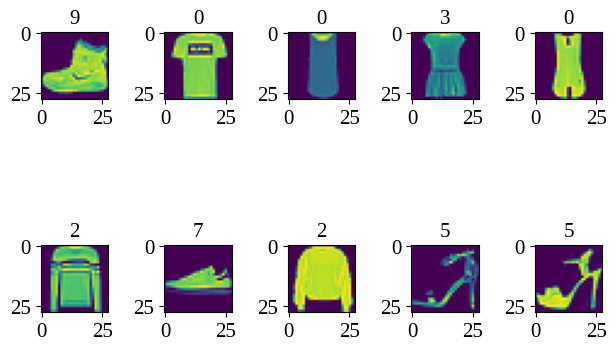

In [64]:
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(train_x[i])
  plt.title(train_y[i])

plt.tight_layout()
plt.savefig("plots_lab_2/fashion_mnist.png")
plt.show()

In [65]:
train_x=pd.DataFrame(train_x.reshape(60000,784))
train_y=pd.DataFrame(train_y)
train_x.head(10)

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,119,114,130,76,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,22,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,33,96,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,0,22,...,0,0,0,0,133,167,73,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,1,1,0,0,0,...,0,0,3,0,82,237,231,70,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [66]:
train_y.head(10)

,0
0,9
1,0
2,0
3,3
4,0
5,2
6,7
7,2
8,5
9,5


In [67]:
test_x=pd.DataFrame(test_x.reshape(10000,784))
test_y=pd.DataFrame(test_y)

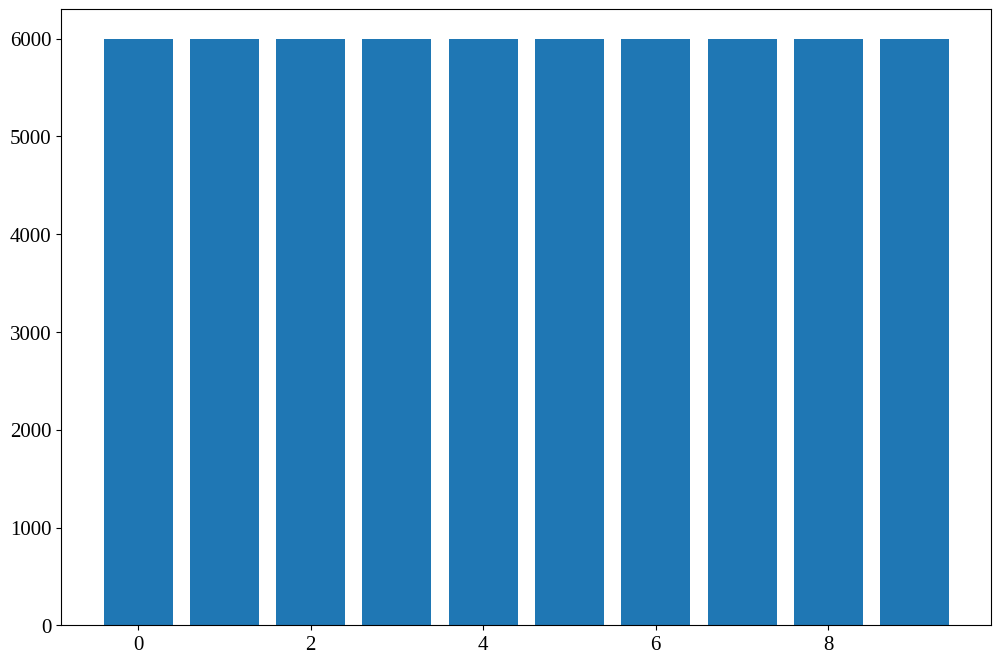

In [68]:
plt.figure(figsize=(12,8))
plt.bar(train_y[0].value_counts().index,train_y[0].value_counts().values)
plt.show()

In [12]:
train_y_one_hot=tf.keras.utils.to_categorical(train_y,num_classes=10)
test_y_one_hot=tf.keras.utils.to_categorical(test_y,num_classes=10)

print(f"Original train_y shape: {train_y.shape}")
print(f"One-hot encoded train_y shape: {train_y_one_hot.shape}")
print(f"Original test_y shape: {test_y.shape}")
print(f"One-hot encoded test_y shape: {test_y_one_hot.shape}")

Original train_y shape: (60000, 1)
One-hot encoded train_y shape: (60000, 10)
Original test_y shape: (10000, 1)
One-hot encoded test_y shape: (10000, 10)


In [13]:
mm=MinMaxScaler()
train_x=mm.fit_transform(train_x)
test_x=mm.transform(test_x)

In [14]:
train_x = pd.DataFrame(train_x)
train_x.head()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.004348,0.0,0.0,0.000000,0.000000,...,0.466667,0.447059,0.509804,0.298039,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.086275,...,0.000000,0.000000,0.003922,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.129921,0.376471,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
train_x.shape

(60000, 784)

In [16]:
test_x.shape

(10000, 784)

In [17]:
train_y.shape

(60000, 1)

In [18]:
test_y.shape

(10000, 1)

In [19]:
model=Sequential([
    Input(shape=(784,)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [48]:
history=model.fit(
    train_x,
    train_y_one_hot,
    batch_size=32,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5979 - loss: 3.6877 - val_accuracy: 0.6314 - val_loss: 1.2982
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6507 - loss: 1.0770 - val_accuracy: 0.5996 - val_loss: 1.3213
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6647 - loss: 0.9973 - val_accuracy: 0.7239 - val_loss: 0.8660
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7151 - loss: 0.8773 - val_accuracy: 0.7085 - val_loss: 0.9199
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7301 - loss: 0.7977 - val_accuracy: 0.7692 - val_loss: 0.8018
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7130 - loss: 0.8431 - val_accuracy: 0.7163 - val_loss: 0.7727
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7420 - loss: 0.7585 - val_accuracy: 0.7502 - val_loss: 0.7215
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7753 - loss: 0.7234 - 

In [23]:
pred_y=model.predict(test_x)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [24]:
pred_y=np.argmax(pred_y, axis=1)
test_y=test_y.values.ravel()

In [25]:
print("Accuracy:", accuracy_score(test_y, pred_y))
print("Precision:", precision_score(test_y, pred_y, average="weighted"))
print("Recall:", recall_score(test_y, pred_y, average="weighted"))
print("F1 Score:", f1_score(test_y, pred_y, average="weighted"))

Accuracy: 0.8842
Precision: 0.8857707291670569
Recall: 0.8842
F1 Score: 0.8840158230139122


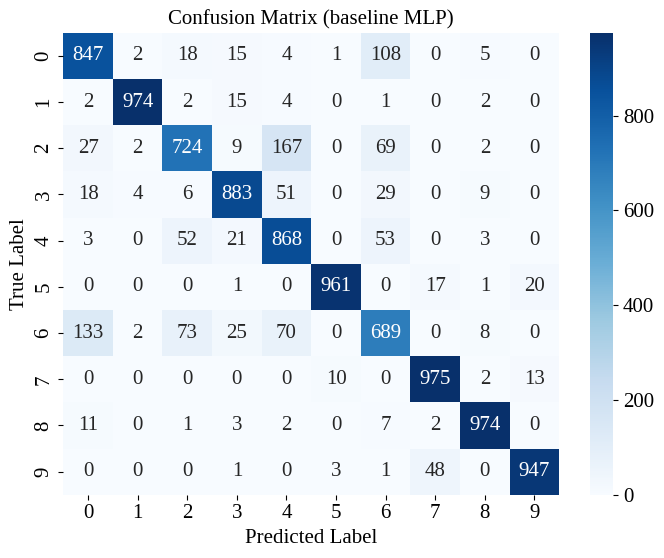

In [77]:
cm=confusion_matrix(test_y, pred_y)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=range(10),yticklabels=range(10))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (baseline MLP)")

plt.savefig(
    "plots_lab_2/confusion_matrix_baseline.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [27]:
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.83      0.72      0.77      1000
           3       0.91      0.88      0.90      1000
           4       0.74      0.87      0.80      1000
           5       0.99      0.96      0.97      1000
           6       0.72      0.69      0.70      1000
           7       0.94      0.97      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



In [28]:
def create_model(hidden_layers=2,hidden_neurons=128,learning_rate=0.001,optimizer="adam",activation="relu",dropout_rate=0.0):

    model=Sequential()
    model.add(Input(shape=(784,)))

    activation=activation.lower()

    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation="softmax"))

    optimizer = optimizer.lower()

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt,loss="sparse_categorical_crossentropy",metrics=["accuracy"])

    return model

In [29]:
clf=KerasClassifier(model=create_model,verbose=0)

In [30]:
param_dist={
    "model__hidden_layers":[1,2,3],
    "model__hidden_neurons":[32, 64, 128, 256],
    "model__learning_rate":[0.1, 0.01, 0.001],
    "model__optimizer":["adam","sgd","rmsprop"],
    "model__activation":["relu","tanh","sigmoid"],
    "batch_size":[16, 32, 64, 128],
    "epochs":[10, 20, 30]
}

In [31]:
random_search=RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring="accuracy",
    random_state=42
)

train_y=train_y.values.ravel()
random_search.fit(train_x, train_y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'batch_size': [16, 32, ...], 'epochs': [10, 20, ...], 'model__activation': ['relu', 'tanh', ...], 'model__hidden_layers': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` inst

In [32]:
print("Best Parameters:")
print(random_search.best_params_)

print()

print("Best Cross Validation Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'model__optimizer': 'sgd', 'model__learning_rate': 0.1, 'model__hidden_neurons': 256, 'model__hidden_layers': 3, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 128}

Best Cross Validation Accuracy:
0.8934333333333333


In [33]:
best_model=random_search.best_estimator_
pred=best_model.predict(test_x)

print("Optimized Accuracy:",accuracy_score(test_y,pred))
print("Precision:",precision_score(test_y,pred,average="weighted"))
print("Recall:",recall_score(test_y,pred,average="weighted"))
print("F1 Score:",f1_score(test_y,pred,average="weighted"))

Optimized Accuracy: 0.8823
Precision: 0.8862129884473874
Recall: 0.8823
F1 Score: 0.8822401869309655


In [34]:
best_params=random_search.best_params_
optimized_model=Sequential()
optimized_model.add(Input(shape=(784,)))
for i in range(best_params["model__hidden_layers"]):
    optimized_model.add(
        Dense(
            best_params["model__hidden_neurons"],
            activation=best_params["model__activation"]
        )
    )

optimized_model.add(Dense(10, activation="softmax"))
if best_params["model__optimizer"]=="adam":
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=best_params["model__learning_rate"]
    )
elif best_params["model__optimizer"]=="sgd":
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=best_params["model__learning_rate"]
    )
else:
    optimizer=tf.keras.optimizers.RMSprop(
        learning_rate=best_params["model__learning_rate"]
    )

optimized_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_opt=optimized_model.fit(
    train_x,
    train_y,
    batch_size=best_params["batch_size"],
    epochs=best_params["epochs"],
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7819 - loss: 0.6059 - val_accuracy: 0.8261 - val_loss: 0.4705
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8357 - loss: 0.4527 - val_accuracy: 0.8264 - val_loss: 0.4836
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8503 - loss: 0.4117 - val_accuracy: 0.8381 - val_loss: 0.4546
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8586 - loss: 0.3888 - val_accuracy: 0.8358 - val_loss: 0.4445
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8635 - loss: 0.3688 - val_accuracy: 0.8574 - val_loss: 0.3892
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8700 - loss: 0.3525 - val_accuracy: 0.8602 - val_loss: 0.3837
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8760 - loss: 0.3380 - val_accuracy: 0.8737 - val_loss: 0.3457
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8788 - loss: 0.3286 - val_accuracy: 0.

In [35]:
pred_opt=optimized_model.predict(test_x)
pred_opt=np.argmax(pred_opt, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [36]:
print("Optimized Accuracy:", accuracy_score(test_y, pred_opt))
print("Optimized Precision:", precision_score(test_y, pred_opt, average="weighted"))
print("Optimized Recall:", recall_score(test_y, pred_opt, average="weighted"))
print("Optimized F1 Score:", f1_score(test_y, pred_opt, average="weighted"))

Optimized Accuracy: 0.8851
Optimized Precision: 0.8861256686764653
Optimized Recall: 0.8851
Optimized F1 Score: 0.8845466896391626


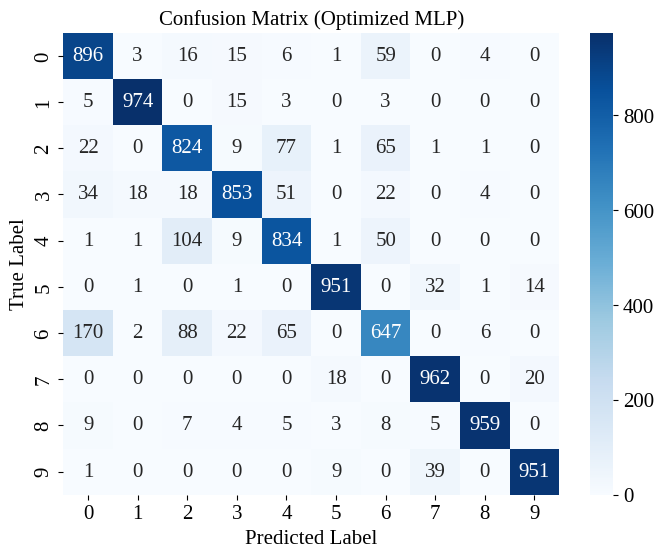

In [76]:
cm=confusion_matrix(test_y, pred_opt)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=range(10),yticklabels=range(10))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Optimized MLP)")

plt.savefig(
    "plots_lab_2/confusion_matrix_optimized.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [38]:
print("\nClassification Report")
print(classification_report(test_y, pred_opt))


Classification Report
              precision    recall  f1-score   support

           0       0.79      0.90      0.84      1000
           1       0.97      0.97      0.97      1000
           2       0.78      0.82      0.80      1000
           3       0.92      0.85      0.88      1000
           4       0.80      0.83      0.82      1000
           5       0.97      0.95      0.96      1000
           6       0.76      0.65      0.70      1000
           7       0.93      0.96      0.94      1000
           8       0.98      0.96      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.88     10000



In [39]:
comparison=pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline": [
        accuracy_score(test_y, pred_y),
        precision_score(test_y, pred_y, average="weighted"),
        recall_score(test_y, pred_y, average="weighted"),
        f1_score(test_y, pred_y, average="weighted")
    ],
    "Optimized": [
        accuracy_score(test_y, pred),
        precision_score(test_y, pred, average="weighted"),
        recall_score(test_y, pred, average="weighted"),
        f1_score(test_y, pred, average="weighted")
    ]
})

print(comparison)

      Metric  Baseline  Optimized
0   Accuracy  0.884200   0.882300
1  Precision  0.885771   0.886213
2     Recall  0.884200   0.882300
3   F1 Score  0.884016   0.882240


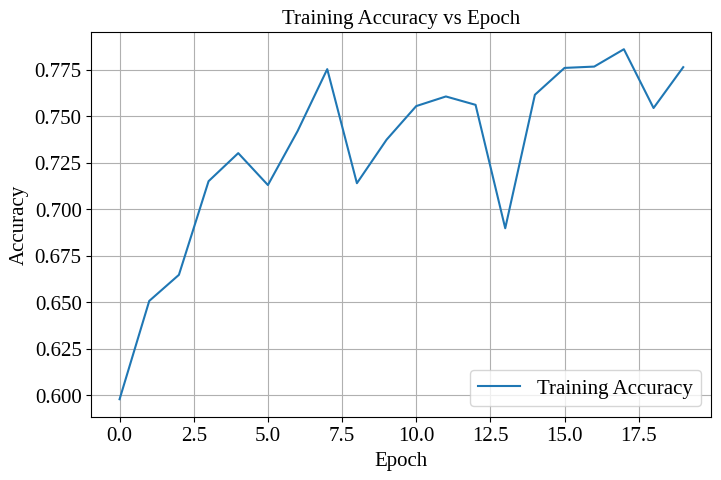

In [71]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Training Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.grid(True)
plt.legend()

plt.savefig(
    "plots_lab_2/training_accuracy.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

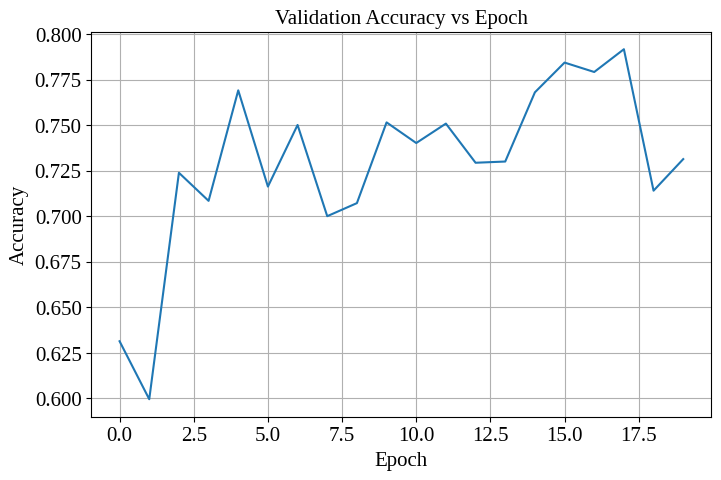

In [73]:
plt.figure(figsize=(8,5))
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.grid(True)

plt.savefig(
    "plots_lab_2/validation_accuracy.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

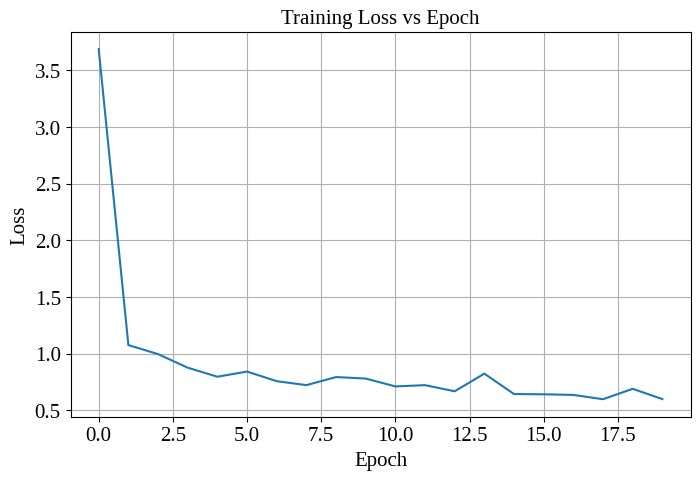

In [74]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)

plt.savefig(
    "plots_lab_2/training_loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

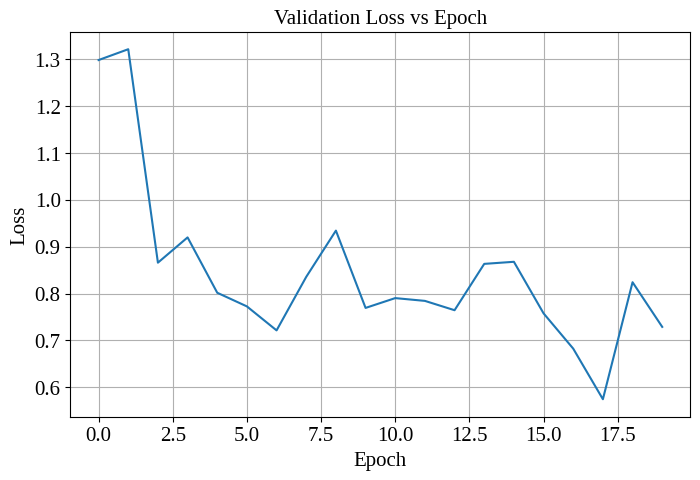

In [75]:
plt.figure(figsize=(8,5))
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss vs Epoch")
plt.grid(True)

plt.savefig(
    "plots_lab_2/validation_loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

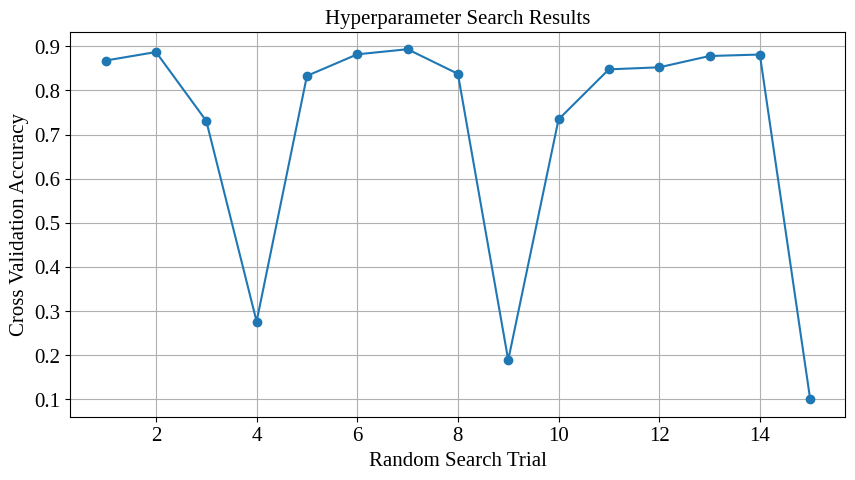

In [78]:
results=pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(10,5))
plt.plot(range(1,len(results)+1),results["mean_test_score"],marker="o")

plt.xlabel("Random Search Trial")
plt.ylabel("Cross Validation Accuracy")
plt.title("Hyperparameter Search Results")
plt.grid(True)

plt.savefig(
    "plots_lab_2/hyperparameter_search_results.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

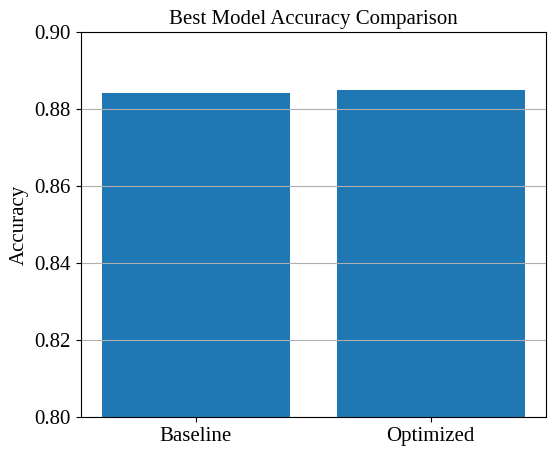

In [80]:
plt.figure(figsize=(6,5))

plt.bar(["Baseline", "Optimized"],[accuracy_score(test_y, pred_y),accuracy_score(test_y, pred_opt)])

plt.ylabel("Accuracy")
plt.title("Best Model Accuracy Comparison")

plt.ylim(0.80,0.90)

plt.grid(axis="y")

plt.savefig(
    "plots_lab_2/best_model_accuracy_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()